# ECG Signal Processing Workshop — Notebook 4: Multi-Detector Comparison

## Overview

This notebook runs **all major R-peak detection algorithms** available through
NeuroKit2 and WFDB on the same ECG recordings, then evaluates every detector
against a high-quality BIOPAC ground truth.

### Detectors under test

| Category | Algorithm | Key Idea |
|---|---|---|
| **Derivative + threshold** | `neurokit` (NeuroKit2 default) | Bandpass → squared gradient → adaptive threshold |
| | `pantompkins1985` | Classic bandpass → derivative → squaring → MWI |
| | `hamilton2002` | Improved Pan-Tompkins with adaptive search-back |
| **Template / morphology** | `christov2004` | Complex lead, steep-slope search, adaptive threshold |
| | `gamboa2008` | First-order derivative zero-crossing with dynamic threshold |
| | `elgendi2010` | Two moving-average filters generating blocks of interest |
| **Wavelet / hybrid** | `engzeemod2012` | Modified Engelse-Zeelenberg with digital filter |
| | `kalidas2017` | Adaptive threshold on squared first difference |
| | `rodrigues2021` | Multi-scale mathematical morphology |
| **Ensemble** | `promac` (PROMAC) | Probabilistic Multi-method Aggregation Consensus |
| **External** | WFDB `XQRS` | WFDB's learning QRS detector (slope/amplitude/width) |

### Evaluation metrics

Every detector is scored against the BIOPAC reference using beat-level metrics
(±50 ms tolerance):

- **Sensitivity (Se)** — proportion of true beats detected
- **Positive Predictive Value (PPV)** — proportion of detections that are true beats
- **F1 score** — harmonic mean of Se and PPV
- **Compute time** — wall-clock time per detector call

### Notebook outline

1. Imports & file paths
2. Data loading & preprocessing
3. BIOPAC ground truth (CH40 reference + CH43 cross-validation)
4. NeuroKit2 detector family
5. WFDB XQRS detector
6. PROMAC ensemble detector
7. Beat-level evaluation
8. Results tables & heatmaps
9. Timing comparison
10. R-peak overlay plots
11. RR-interval comparison
12. Bland-Altman analysis
13. Summary & recommendations

## 1. Environment Setup

All imports and user-configurable file paths live here so the notebook is
self-contained and easy to adapt to new recordings.

In [34]:
# =====================================================================
# USER CONFIGURATION
# =====================================================================
BIOPAC_FILE_PATH = r"sample_data/BIOPAC_04020062_9_Female_1st.txt"
BELT_FILE_PATH   = r"sample_data/BABY_BELT_04020062_9_Female_1st.csv"
# --- Dataset format selector ---
DATASET_FORMAT = "CAREWEAR"  # Options: "BABY_BELT" or "CAREWEAR"
# --- CareWear paths ---
# CAREWEAR_BIOPAC_FILE_PATH = r"sample_data/CAREWEAR/P10-stationary Bike1-biopac-01-30-2025.txt"
# CAREWEAR_BELT_FILE_PATH   = r"sample_data/CAREWEAR/P10-stationary Bike1-belt-01-30-2025"
CAREWEAR_BIOPAC_FILE_PATH = r"sample_data/CAREWEAR/P27-stationaryBike2-biopac-07-02-2025.txt"
CAREWEAR_BELT_FILE_PATH   = r"sample_data/CAREWEAR/P27-stationaryBike2-belt-07-02-2025"

CAREWEAR_BIOPAC_ECG_COL   = "CH9"   # "CH9" (raw ECG) or "CH40" (AHA-filtered)

CAREWEAR_BELT_ECG_MODE = "NORMALIZE"  # "MAX30003" = hardware mV (_max30003_convert); "NORMALIZE" = float cast only, then parser zero-mean / z-score (no bit unpack)

def _max30003_convert(raw_int32):
    """Convert raw MAX30003 FIFO values to millivolts.

    Sign-extend 24-bit ECG word, strip 6 tag bits, scale by
    1000 / (131072 * 20) ≈ 0.000381 mV/count (VREF=1V, GAIN=20).
    Interpolates over invalid (fast-recovery/overflow) samples.
    Returns zero-mean float64 array.
    """
    raw = np.asarray(raw_int32, dtype=np.int64)
    raw_u24 = raw & 0xFFFFFF
    etag = (raw_u24 >> 3) & 0x07
    valid = (etag == 0) | (etag == 2)
    raw_s32 = np.where(raw_u24 >= 0x800000, raw_u24 - 0x1000000, raw_u24).astype(np.int32)
    ecg18 = np.right_shift(raw_s32, 6)
    LSB_MV = 1000.0 / (131072.0 * 20.0)
    mv = ecg18.astype(np.float64) * LSB_MV
    mv[~valid] = np.nan
    nans = np.isnan(mv)
    if nans.any():
        ok = np.where(~nans)[0]
        if len(ok) > 1:
            mv = np.interp(np.arange(len(mv)), ok, mv[ok])
        else:
            mv[:] = 0.0
    mv -= np.mean(mv)
    return mv

CAREWEAR_BELT_ECG_SCALE_FN = (
    _max30003_convert if CAREWEAR_BELT_ECG_MODE == "MAX30003" else None
)
OUTPUT_DIR       = r"outputs/NB04"
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import os
import warnings

from scipy.signal import butter, sosfiltfilt, iirnotch, tf2sos, medfilt
from tqdm.notebook import tqdm

import neurokit2 as nk
import wfdb.processing as wfdb_proc

warnings.filterwarnings("ignore")
np.random.seed(42)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory ready: {os.path.abspath(OUTPUT_DIR)}")

Output directory ready: C:\Users\viggi\Documents\Github\WBL-ECG-processing_workshop\outputs\NB04


## 2. Data Loading & Preprocessing

Parsers and filter functions are copied inline (identical to NB01/NB02) so this
notebook is fully self-contained.

In [35]:
# -----------------------------------------------------------------
# Parsers
# -----------------------------------------------------------------

def parse_biopac(filepath):
    """Parse BIOPAC AcqKnowledge tab-delimited text export.

    Parameters
    ----------
    filepath : str
        Path to the BIOPAC .txt file.

    Returns
    -------
    df : pd.DataFrame
        Numeric data with columns milliSec, CH1 … CH47, time_s.
    meta : dict
        Recording metadata (filename, recording_time, fs).
    """
    meta = {}
    with open(filepath, "r") as f:
        lines = f.readlines()
    meta["filename"] = lines[0].strip()
    meta["recording_time"] = lines[2].strip().replace("Recording on: ", "")
    meta["fs"] = 1000
    col_names = [
        "milliSec", "CH1", "CH2", "CH3", "CH40", "CH41", "CH42",
        "CH43", "CH44", "CH45", "CH46", "CH47", "_extra",
    ]
    df = pd.read_csv(
        filepath, sep="\t", skiprows=29, header=None,
        names=col_names, on_bad_lines="skip",
    )
    df = df.drop(columns=["_extra"], errors="ignore")
    df = df.dropna(subset=["CH40"])
    df["time_s"] = df["milliSec"] / 1000.0
    return df, meta


def parse_belt(filepath):
    """Parse Baby Belt BLE-streamed CSV.

    Resamples the jittered BLE stream onto a uniform 100 Hz grid
    via linear interpolation.

    Parameters
    ----------
    filepath : str
        Path to the belt .csv file.

    Returns
    -------
    df : pd.DataFrame
        Raw belt DataFrame.
    ecg_interp : np.ndarray
        Uniformly resampled ECG (ADC counts).
    t_uniform : np.ndarray
        Uniform time vector (seconds).
    fs_nominal : int
        Nominal sampling rate (100 Hz).
    """
    df = pd.read_csv(filepath)
    df["time_s"] = (df["Tx_ms"] - df["Tx_ms"].iloc[0]) / 1000.0
    df["seq_gap"] = df["Seq"].diff() > 1
    fs_nominal = 100
    t_uniform = np.arange(0, df["time_s"].iloc[-1], 1 / fs_nominal)
    ecg_interp = np.interp(t_uniform, df["time_s"].values, df["ECG"].values)
    return df, ecg_interp, t_uniform, fs_nominal


# -----------------------------------------------------------------
# Filters
# -----------------------------------------------------------------

def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=5):
    """Zero-phase Butterworth bandpass filter.

    Parameters
    ----------
    signal : np.ndarray
        Input signal.
    fs : int
        Sampling frequency (Hz).
    lowcut, highcut : float
        Passband edges (Hz).
    order : int
        Filter order.

    Returns
    -------
    np.ndarray
        Filtered signal.
    """
    sos = butter(order, [lowcut, highcut], btype="band", fs=fs, output="sos")
    return sosfiltfilt(sos, signal)


def notch_filter(signal, fs, freq=60.0, quality=30.0):
    """Zero-phase IIR notch filter for powerline removal.

    Parameters
    ----------
    signal : np.ndarray
        Input signal.
    fs : int
        Sampling frequency (Hz).
    freq : float
        Notch centre frequency (Hz).
    quality : float
        Quality factor.

    Returns
    -------
    np.ndarray
        Filtered signal.
    """
    nyquist = fs / 2.0
    if freq >= 0.9 * nyquist:
        print(f'  [notch_filter] Skipping {freq:.0f} Hz notch — '
              f'too close to Nyquist ({nyquist:.0f} Hz) for fs={fs:.0f} Hz')
        return signal
    b, a = iirnotch(freq, quality, fs)
    sos = tf2sos(b, a)
    return sosfiltfilt(sos, signal)


def remove_baseline(signal, fs):
    """Remove baseline wander via cascaded median filters.

    Parameters
    ----------
    signal : np.ndarray
        Input signal.
    fs : int
        Sampling frequency (Hz).

    Returns
    -------
    np.ndarray
        Baseline-corrected signal.
    """
    win1 = int(0.2 * fs) | 1
    win2 = int(0.6 * fs) | 1
    baseline = medfilt(medfilt(signal, win1), win2)
    return signal - baseline


# ===================== CareWear BIOPAC Parser =====================

def parse_carewear_biopac(filepath, ecg_col=None):
    """Parse CareWear BIOPAC AcqKnowledge exported .txt file.

    Reads a variable-length header, auto-detects sampling rate
    and column layout, returns (df, meta) matching parse_biopac().

    Parameters
    ----------
    filepath : str
        Path to the CareWear BIOPAC .txt export file.
    ecg_col : str or None
        Column to use as primary ECG (default: CAREWEAR_BIOPAC_ECG_COL).

    Returns
    -------
    df : pd.DataFrame
        Numeric data with columns milliSec, CH5, CH9, CH40, etc., time_s.
    meta : dict
        Recording metadata (filename, recording_time, fs).
    """
    if ecg_col is None:
        ecg_col = CAREWEAR_BIOPAC_ECG_COL

    meta = {}
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    meta["filename"] = lines[0].strip()
    sample_rate_ms = None
    header_idx = None

    for idx, line in enumerate(lines):
        stripped = line.strip()
        if not stripped:
            continue
        if "msec/sample" in stripped and sample_rate_ms is None:
            sample_rate_ms = float(stripped.split()[0])
        if stripped.startswith("Recording on:"):
            meta["recording_time"] = stripped.split(": ", 1)[1]
        if stripped.startswith("milliSec"):
            header_idx = idx
            break

    if sample_rate_ms is None:
        raise ValueError("Could not find sample rate (msec/sample) in header.")
    if header_idx is None:
        raise ValueError("Could not find data header row starting with milliSec.")

    meta["fs"] = int(round(1000.0 / sample_rate_ms))

    col_names = [c.strip() for c in lines[header_idx].strip().split("\t") if c.strip()]

    from io import StringIO
    data_text = "".join(lines[header_idx + 2 :])
    df = pd.read_csv(StringIO(data_text), sep="\t", header=None, on_bad_lines="skip")
    df = df.dropna(how="all", axis=1)
    df.columns = col_names[: len(df.columns)]

    if ecg_col not in df.columns:
        raise ValueError(f"ECG column '{ecg_col}' not found. Available: {list(df.columns)}")

    df = df.dropna(subset=[ecg_col])
    df["time_s"] = df["milliSec"] / 1000.0
    return df, meta



# ===================== CareWear Belt Parser =====================

def parse_carewear_belt(filepath, ecg_scale_fn=None):
    """Parse CareWear belt data file (CSV with Unix epoch timestamps).

    Reads the CSV, converts epoch timestamps to relative seconds,
    z-score normalises Channel 4 (ECG), and resamples onto a uniform
    grid.  Returns (df, ecg_interp, t_uniform, fs_nominal) matching
    parse_belt().

    Parameters
    ----------
    filepath : str
        Path to the CareWear belt data file.
    ecg_scale_fn : callable or None
        Optional scaling applied to raw ECG before normalisation.
        Defaults to CAREWEAR_BELT_ECG_SCALE_FN.

    Returns
    -------
    df : pd.DataFrame
        Raw DataFrame with added time_s and seq_gap columns.
    ecg_interp : np.ndarray
        ECG resampled to a uniform grid (z-score normalised).
    t_uniform : np.ndarray
        Uniform time axis in seconds.
    fs_nominal : int
        Estimated sampling rate in Hz.
    Uses CAREWEAR_BELT_ECG_MODE / CAREWEAR_BELT_ECG_SCALE_FN from the config cell:
    MAX30003 applies the FIFO unpack + mV scaling; NORMALIZE skips that and uses
    float Channel 4 values with mean removal and/or z-score in this parser.
"""
    if ecg_scale_fn is None:
        ecg_scale_fn = CAREWEAR_BELT_ECG_SCALE_FN

    df = pd.read_csv(filepath)
    ts = df["timestamp"].values.astype(np.float64)
    df["time_s"] = (ts - ts[0]) / 1000.0

    ecg_raw_int = df["Channel 4"].values.astype(np.int32)
    if ecg_scale_fn is not None:
        ecg_raw = ecg_scale_fn(ecg_raw_int).astype(np.float64)
    else:
        ecg_raw = ecg_raw_int.astype(np.float64)

    ecg_mean, ecg_std = np.mean(ecg_raw), np.std(ecg_raw)
    ecg_norm = (ecg_raw - ecg_mean) / ecg_std if ecg_std > 0 else ecg_raw - ecg_mean

    dt_ms = np.median(np.diff(ts))
    fs_nominal = int(round(1000.0 / dt_ms))

    t_uniform = np.arange(0, df["time_s"].iloc[-1], 1.0 / fs_nominal)
    ecg_interp = np.interp(t_uniform, df["time_s"].values, ecg_norm)
    df["seq_gap"] = False

    return df, ecg_interp, t_uniform, fs_nominal


# ----- Wavelet Reconstruction (optional) -----

HAS_SSQ_NB04 = False
try:
    from ssqueezepy import ssq_cwt
    HAS_SSQ_NB04 = True
except ImportError:
    pass


def ssq_ecg_band_reconstruct(signal, fs, fmin=5, fmax=40):
    """Reconstruct ECG from SSQ-CWT within a frequency band.

    Parameters
    ----------
    signal : np.ndarray
        Input signal.
    fs : float
        Sampling frequency in Hz.
    fmin, fmax : float
        Frequency band limits.

    Returns
    -------
    np.ndarray
        Reconstructed signal.
    """
    if not HAS_SSQ_NB04:
        return bandpass_filter(signal, fs, fmin, fmax)
    Tx, Wx, ssq_freqs, scales, *_ = ssq_cwt(signal, fs=fs)
    band_mask = (ssq_freqs >= fmin) & (ssq_freqs <= fmax)
    Tx_band = np.zeros_like(Tx)
    Tx_band[band_mask, :] = Tx[band_mask, :]
    return np.real(Tx_band.real.sum(axis=0))


In [36]:
# -----------------------------------------------------------------
# Load data
# -----------------------------------------------------------------
if DATASET_FORMAT == "CAREWEAR":
    biopac_df, biopac_meta = parse_carewear_biopac(CAREWEAR_BIOPAC_FILE_PATH)
    belt_df, belt_ecg_raw, belt_time, belt_fs = parse_carewear_belt(CAREWEAR_BELT_FILE_PATH)
else:
    biopac_df, biopac_meta = parse_biopac(BIOPAC_FILE_PATH)
    belt_df, belt_ecg_raw, belt_time, belt_fs = parse_belt(BELT_FILE_PATH)

biopac_fs = biopac_meta["fs"]

print(f"BIOPAC  : {len(biopac_df)} samples @ {biopac_fs} Hz  "
      f"({biopac_df['time_s'].iloc[-1]:.1f} s)")
_belt_label = "CareWear Belt" if DATASET_FORMAT == "CAREWEAR" else "Baby Belt"
print(f"Belt    : {len(belt_ecg_raw)} samples @ {belt_fs} Hz  "
      f"({belt_time[-1]:.1f} s)")

# -----------------------------------------------------------------
# BIOPAC ECG = CH40 (hardware 0.05–100 Hz AHA). CH1 is sync/aux — not used as ECG.
# Full software pipeline (same order as NB02): notch -> bandpass -> baseline removal.
# -----------------------------------------------------------------
biopac_mask = biopac_df["time_s"] >= 0
if DATASET_FORMAT == "CAREWEAR":
    _ecg_col = CAREWEAR_BIOPAC_ECG_COL
else:
    _ecg_col = "CH40"
biopac_ecg_ch40 = biopac_df.loc[biopac_mask, _ecg_col].values.astype(np.float64)

biopac_ecg_clean = remove_baseline(
    bandpass_filter(
        notch_filter(biopac_ecg_ch40, biopac_fs, 60.0),
        biopac_fs, 0.5, 40.0,
    ),
    biopac_fs,
)

# Belt: notch -> bandpass -> baseline -> wavelet reconstruction
belt_notched = notch_filter(belt_ecg_raw, belt_fs, 60.0)
belt_bp = bandpass_filter(belt_notched, belt_fs, 0.5, 40.0)
belt_bl_removed = remove_baseline(belt_bp, belt_fs)
belt_ecg_clean = ssq_ecg_band_reconstruct(belt_bl_removed, belt_fs, fmin=5, fmax=40)
_belt_label = "CareWear Belt" if DATASET_FORMAT == "CAREWEAR" else "Baby Belt"
print(f"Belt preprocessing: notch -> bandpass -> baseline -> wavelet reconstruction")

print("\nPreprocessing complete.")
# Auto-correct signal inversion: ECG R-peaks should create positive skew.
# If skewness is negative the signal is flipped; invert it.
try:
    from scipy.stats import skew as _ecg_skew
    _bl_skew = float(_ecg_skew(belt_ecg_clean))
    if _bl_skew < 0:
        belt_ecg_clean = -belt_ecg_clean
        print(f"Belt ECG auto-inverted (skewness was {_bl_skew:.2f})")
    else:
        print(f"Belt ECG orientation OK (skewness {_bl_skew:.2f})")
except Exception:
    pass


BIOPAC  : 37501 samples @ 125 Hz  (300.0 s)
Belt    : 29974 samples @ 100 Hz  (299.7 s)
  [notch_filter] Skipping 60 Hz notch — too close to Nyquist (62 Hz) for fs=125 Hz
  [notch_filter] Skipping 60 Hz notch — too close to Nyquist (50 Hz) for fs=100 Hz
Belt preprocessing: notch -> bandpass -> baseline -> wavelet reconstruction

Preprocessing complete.
Belt ECG auto-inverted (skewness was -3.02)


## 3. BIOPAC Ground Truth

The ECG waveform is **CH40** (0.05–100 Hz AHA hardware filter in the MP160).
**CH1 is sync/auxiliary — not used as ECG** in this workshop.

Reference R-peaks come from NeuroKit2 **`ecg_process`** run on the **same
software pipeline** as the detectors: 60 Hz notch (when below Nyquist),
0.5–40 Hz bandpass, and double-median baseline removal applied to CH40.
We cross-validate by comparing the detected count against
**CH43** (BIOPAC's own R-wave amplitude marker, non-zero wherever
AcqKnowledge internally flagged an R-wave).

In [37]:
# -----------------------------------------------------------------
# Reference R-peaks (NeuroKit2 ecg_process on CH40 after full software pipeline)
# -----------------------------------------------------------------
ref_signals, ref_info = nk.ecg_process(biopac_ecg_clean, sampling_rate=biopac_fs)
ref_peaks = np.where(ref_signals["ECG_R_Peaks"].values == 1)[0]

# Cross-validate with CH43 R-wave markers (if available)
if "CH43" in biopac_df.columns:
    biopac_ch43 = biopac_df.loc[biopac_mask, "CH43"].values.astype(np.float64)
    biopac_rwave_markers = np.where(np.abs(biopac_ch43) > 0.01)[0]
else:
    biopac_rwave_markers = np.array([], dtype=int)
    print("  CH43 column not available in this dataset.")

# CH43 fires a pulse spanning several samples per beat — count clusters
if len(biopac_rwave_markers) > 0:
    gaps = np.diff(biopac_rwave_markers)
    ch43_beat_count = 1 + np.sum(gaps > biopac_fs * 0.2)
else:
    ch43_beat_count = 0

print(f"Reference peaks (NeuroKit2 on CH40) : {len(ref_peaks)}")
print(f"BIOPAC R-wave markers (CH43 clusters): {ch43_beat_count}")
print(f"Difference                           : {abs(len(ref_peaks) - ch43_beat_count)}")

Reference peaks (NeuroKit2 on CH40) : 456
BIOPAC R-wave markers (CH43 clusters): 1
Difference                           : 455


## 4. NeuroKit2 Detector Family

NeuroKit2 exposes nine classical R-peak detectors through a single
`ecg_peaks()` interface:

| Method | Reference | Core technique |
|---|---|---|
| `neurokit` | Makowski et al. 2021 | Bandpass gradient with adaptive threshold |
| `pantompkins1985` | Pan & Tompkins 1985 | Differentiation → squaring → MWI |
| `hamilton2002` | Hamilton 2002 | Adaptive thresholds with search-back |
| `christov2004` | Christov 2004 | Complex-lead steep slope + adaptive threshold |
| `gamboa2008` | Gamboa 2008 | 1st derivative + dynamic threshold |
| `elgendi2010` | Elgendi et al. 2010 | Dual moving-average blocks of interest |
| `engzeemod2012` | Lourenco et al. 2012 | Modified Engelse-Zeelenberg |
| `kalidas2017` | Kalidas & Tamil 2017 | Adaptive threshold on squared 1st difference |
| `rodrigues2021` | Rodrigues et al. 2021 | Multi-scale mathematical morphology |

We also include **PROMAC** (Probabilistic Multi-method Aggregation
Consensus), which internally runs several detectors and returns a
consensus — useful as a high-accuracy but expensive option.

In [38]:
NK2_METHODS = [
    "neurokit", "pantompkins1985", "hamilton2002",
    "christov2004", "gamboa2008", "elgendi2010",
    "engzeemod2012", "kalidas2017", "rodrigues2021",
]


def run_all_detectors(ecg_signal, fs, methods=NK2_METHODS):
    """Run multiple NeuroKit2 R-peak detection algorithms with timing.

    Parameters
    ----------
    ecg_signal : np.ndarray
        Preprocessed ECG signal.
    fs : int
        Sampling frequency (Hz).
    methods : list of str
        NeuroKit2 method names.

    Returns
    -------
    results : dict
        {method_name: {'peaks': np.ndarray, 'time_ms': float}}
    """
    results = {}
    for method in tqdm(methods, desc="Running NK2 detectors"):
        try:
            start_time = time.perf_counter()
            _, info = nk.ecg_peaks(ecg_signal, sampling_rate=fs, method=method)
            elapsed = (time.perf_counter() - start_time) * 1000
            peaks = np.array(info["ECG_R_Peaks"])
            results[method] = {"peaks": peaks, "time_ms": elapsed}
        except Exception as e:
            print(f"  [{method}] failed: {e}")
            results[method] = {"peaks": np.array([]), "time_ms": 0}
    return results

In [39]:
# -----------------------------------------------------------------
# Run NK2 detectors on BIOPAC CH40 (full pipeline)
# -----------------------------------------------------------------
print("=== BIOPAC CH40 (full pipeline) ===")
biopac_results = run_all_detectors(biopac_ecg_clean, biopac_fs)

for name, res in biopac_results.items():
    print(f"  {name:22s}  peaks={len(res['peaks']):5d}  time={res['time_ms']:8.1f} ms")

=== BIOPAC CH40 (full pipeline) ===


Running NK2 detectors:   0%|          | 0/9 [00:00<?, ?it/s]

  neurokit                peaks=  456  time=    14.9 ms
  pantompkins1985         peaks=  456  time=     5.3 ms
  hamilton2002            peaks=  457  time=    61.5 ms
  christov2004            peaks=  456  time=   547.9 ms
  gamboa2008              peaks=  856  time=     6.3 ms
  elgendi2010             peaks=  457  time=    52.3 ms
  engzeemod2012           peaks=  455  time=   217.0 ms
  kalidas2017             peaks=  457  time=     7.2 ms
  rodrigues2021           peaks=  457  time=    30.1 ms


In [40]:
# -----------------------------------------------------------------
# Run NK2 detectors on Belt ECG (preprocessed)
# -----------------------------------------------------------------
print("=== Belt ECG (preprocessed) ===")
belt_results = run_all_detectors(belt_ecg_clean, belt_fs)

for name, res in belt_results.items():
    print(f"  {name:22s}  peaks={len(res['peaks']):5d}  time={res['time_ms']:8.1f} ms")

=== Belt ECG (preprocessed) ===


Running NK2 detectors:   0%|          | 0/9 [00:00<?, ?it/s]

  neurokit                peaks=  456  time=    14.0 ms
  pantompkins1985         peaks=  456  time=     5.1 ms
  hamilton2002            peaks=  457  time=    68.3 ms
  christov2004            peaks=  431  time=   475.3 ms
  gamboa2008              peaks=  778  time=     5.4 ms
  elgendi2010             peaks=  458  time=    46.2 ms
  engzeemod2012           peaks=  370  time=   169.2 ms
  kalidas2017             peaks=  378  time=     4.7 ms
  rodrigues2021           peaks=  428  time=    27.6 ms


## 5. WFDB XQRS Detector

The **XQRS** detector from the WFDB library uses a learning phase to
adapt amplitude/slope/width thresholds to the specific signal, then
applies those thresholds in a detection pass. It is widely used in
PhysioNet-based research.

In [51]:
def run_xqrs(ecg_signal, fs):
    """Run the WFDB XQRS R-peak detector with timing.

    Parameters
    ----------
    ecg_signal : np.ndarray
        Input ECG signal.
    fs : int
        Sampling frequency (Hz).

    Returns
    -------
    dict
        {'peaks': np.ndarray, 'time_ms': float}
    """
    try:
        start_time = time.perf_counter()
        xqrs = wfdb_proc.XQRS(sig=ecg_signal.astype(np.float64), fs=int(fs))
        xqrs.detect(learn=True, verbose=False)
        elapsed = (time.perf_counter() - start_time) * 1000
        return {"peaks": np.array(xqrs.qrs_inds), "time_ms": elapsed}
    except Exception as e:
        print(f"  [XQRS] failed: {e}")
        return {"peaks": np.array([]), "time_ms": 0}


# BIOPAC
xqrs_biopac = run_xqrs(biopac_ecg_clean, biopac_fs)
biopac_results["xqrs"] = xqrs_biopac
print(f"XQRS on BIOPAC: {len(xqrs_biopac['peaks'])} peaks  "
      f"({xqrs_biopac['time_ms']:.1f} ms)")

# Belt
xqrs_belt = run_xqrs(belt_ecg_clean, belt_fs)
belt_results["xqrs"] = xqrs_belt
print(f"XQRS on Belt  : {len(xqrs_belt['peaks'])} peaks  "
      f"({xqrs_belt['time_ms']:.1f} ms)")

XQRS on BIOPAC: 458 peaks  (100.7 ms)
XQRS on Belt  : 392 peaks  (57.1 ms)


## 6. PROMAC Ensemble Detector

PROMAC (Probabilistic Multi-method Aggregation Consensus) is NeuroKit2's
ensemble approach: it runs several underlying detectors, builds a
probability density across the signal, and picks consensus peaks.
This is the **most accurate but slowest** option.

In [52]:
# BIOPAC
try:
    start = time.perf_counter()
    _, promac_info_biopac = nk.ecg_peaks(
        biopac_ecg_clean, sampling_rate=biopac_fs, method="promac"
    )
    elapsed = (time.perf_counter() - start) * 1000
    biopac_results["promac"] = {
        "peaks": np.array(promac_info_biopac["ECG_R_Peaks"]),
        "time_ms": elapsed,
    }
    print(f"PROMAC on BIOPAC: {len(biopac_results['promac']['peaks'])} peaks  "
          f"({elapsed:.1f} ms)")
except Exception as e:
    print(f"PROMAC on BIOPAC failed: {e}")
    biopac_results["promac"] = {"peaks": np.array([]), "time_ms": 0}

# Belt
try:
    start = time.perf_counter()
    _, promac_info_belt = nk.ecg_peaks(
        belt_ecg_clean, sampling_rate=belt_fs, method="promac"
    )
    elapsed = (time.perf_counter() - start) * 1000
    belt_results["promac"] = {
        "peaks": np.array(promac_info_belt["ECG_R_Peaks"]),
        "time_ms": elapsed,
    }
    print(f"PROMAC on Belt  : {len(belt_results['promac']['peaks'])} peaks  "
          f"({elapsed:.1f} ms)")
except Exception as e:
    print(f"PROMAC on Belt failed: {e}")
    belt_results["promac"] = {"peaks": np.array([]), "time_ms": 0}

PROMAC on BIOPAC: 457 peaks  (1311.8 ms)
PROMAC on Belt  : 456 peaks  (1293.1 ms)


## 7. Beat-Level Evaluation

Each detector's output is compared sample-by-sample against the
BIOPAC CH40 reference. A detected peak is a **true positive (TP)** if
it falls within ±50 ms of an unmatched reference peak; otherwise it is
a **false positive (FP)**. Reference peaks with no match are **false
negatives (FN)**.

For the Belt signal we cannot compare directly against a belt-specific
reference (there is none), so we use the BIOPAC reference after
temporal alignment — accepting that sampling-rate differences and BLE
jitter add some noise to the matching.

In [53]:
def evaluate_rpeaks(ref_peaks, test_peaks, fs, tolerance_ms=50):
    """Evaluate R-peak detection accuracy against a reference.

    Uses a greedy nearest-neighbour matcher with a tolerance window.

    Parameters
    ----------
    ref_peaks : np.ndarray
        Reference R-peak sample indices.
    test_peaks : np.ndarray
        Detected R-peak sample indices.
    fs : int
        Sampling frequency (Hz).
    tolerance_ms : float
        Maximum allowed deviation in milliseconds.

    Returns
    -------
    dict
        Keys: TP, FP, FN, Se, PPV, F1.
    """
    if len(ref_peaks) == 0 or len(test_peaks) == 0:
        return dict(TP=0, FP=len(test_peaks), FN=len(ref_peaks),
                    Se=0.0, PPV=0.0, F1=0.0)

    tol = int(tolerance_ms * fs / 1000)
    tp, fp = 0, 0
    matched = set()

    for p in test_peaks:
        diffs = np.abs(ref_peaks - p)
        idx = np.argmin(diffs)
        if diffs[idx] <= tol and idx not in matched:
            tp += 1
            matched.add(idx)
        else:
            fp += 1

    fn = len(ref_peaks) - len(matched)
    se = tp / (tp + fn + 1e-9)
    ppv = tp / (tp + fp + 1e-9)
    f1 = 2 * se * ppv / (se + ppv + 1e-9)
    return dict(TP=tp, FP=fp, FN=fn,
                Se=round(se, 4), PPV=round(ppv, 4), F1=round(f1, 4))

## 8. Results Tables

Build a summary DataFrame for each signal source containing beat-level
metrics **and** compute time for every detector.

In [54]:
# -----------------------------------------------------------------
# Evaluate all BIOPAC detectors against reference
# -----------------------------------------------------------------
biopac_eval_rows = []
for method, res in tqdm(biopac_results.items(), desc="Evaluating BIOPAC"):
    metrics = evaluate_rpeaks(ref_peaks, res["peaks"], biopac_fs)
    metrics["Method"] = method
    metrics["N_detected"] = len(res["peaks"])
    metrics["Time_ms"] = round(res["time_ms"], 2)
    biopac_eval_rows.append(metrics)

biopac_eval_df = pd.DataFrame(biopac_eval_rows)
biopac_eval_df = biopac_eval_df.set_index("Method")
col_order = ["N_detected", "TP", "FP", "FN", "Se", "PPV", "F1", "Time_ms"]
biopac_eval_df = biopac_eval_df[col_order].sort_values("F1", ascending=False)

print("\n=== BIOPAC CH40 (pipeline) — Detector Performance ===")
print(f"Reference peaks: {len(ref_peaks)}")
print(biopac_eval_df.to_string())

Evaluating BIOPAC:   0%|          | 0/11 [00:00<?, ?it/s]


=== BIOPAC CH40 (pipeline) — Detector Performance ===
Reference peaks: 456
                 N_detected   TP   FP   FN      Se     PPV      F1  Time_ms
Method                                                                     
neurokit                456  456    0    0  1.0000  1.0000  1.0000    14.87
christov2004            456  456    0    0  1.0000  1.0000  1.0000   547.94
hamilton2002            457  455    2    1  0.9978  0.9956  0.9967    61.52
promac                  457  455    2    1  0.9978  0.9956  0.9967  1311.85
elgendi2010             457  455    2    1  0.9978  0.9956  0.9967    52.27
engzeemod2012           455  454    1    2  0.9956  0.9978  0.9967   216.97
kalidas2017             457  455    2    1  0.9978  0.9956  0.9967     7.18
rodrigues2021           457  455    2    1  0.9978  0.9956  0.9967    30.14
xqrs                    458  455    3    1  0.9978  0.9934  0.9956   100.66
pantompkins1985         456  347  109  109  0.7610  0.7610  0.7610     5.32
gamboa2008  

In [55]:
# -----------------------------------------------------------------
# Evaluate belt detectors
# For belt we construct a time-based reference: convert BIOPAC ref
# peaks to seconds, then map to belt sample indices.
# -----------------------------------------------------------------
biopac_time_vec = biopac_df.loc[biopac_mask, "time_s"].values
ref_peak_times = biopac_time_vec[ref_peaks]

belt_ref_indices = np.array([
    np.argmin(np.abs(belt_time - t)) for t in ref_peak_times
    if t <= belt_time[-1]
])

belt_eval_rows = []
for method, res in tqdm(belt_results.items(), desc="Evaluating Belt"):
    metrics = evaluate_rpeaks(belt_ref_indices, res["peaks"], belt_fs)
    metrics["Method"] = method
    metrics["N_detected"] = len(res["peaks"])
    metrics["Time_ms"] = round(res["time_ms"], 2)
    belt_eval_rows.append(metrics)

belt_eval_df = pd.DataFrame(belt_eval_rows)
belt_eval_df = belt_eval_df.set_index("Method")
belt_eval_df = belt_eval_df[col_order].sort_values("F1", ascending=False)

print("\n=== Belt ECG — Detector Performance ===")
print(f"Belt-mapped reference peaks: {len(belt_ref_indices)}")
print(belt_eval_df.to_string())

Evaluating Belt:   0%|          | 0/11 [00:00<?, ?it/s]


=== Belt ECG — Detector Performance ===
Belt-mapped reference peaks: 456
                 N_detected   TP   FP   FN      Se     PPV      F1  Time_ms
Method                                                                     
gamboa2008              778  174  604  282  0.3816  0.2237  0.2820     5.35
xqrs                    392    6  386  450  0.0132  0.0153  0.0142    57.13
elgendi2010             458    2  456  454  0.0044  0.0044  0.0044    46.20
hamilton2002            457    0  457  456  0.0000  0.0000  0.0000    68.32
pantompkins1985         456    0  456  456  0.0000  0.0000  0.0000     5.07
neurokit                456    0  456  456  0.0000  0.0000  0.0000    14.05
christov2004            431    0  431  456  0.0000  0.0000  0.0000   475.26
engzeemod2012           370    0  370  456  0.0000  0.0000  0.0000   169.24
kalidas2017             378    0  378  456  0.0000  0.0000  0.0000     4.70
rodrigues2021           428    0  428  456  0.0000  0.0000  0.0000    27.57
promac        

## 9. Plot 1 — Performance Heatmap

Side-by-side heatmaps showing Se, PPV, F1 for each detector on both
BIOPAC raw and Belt signals.

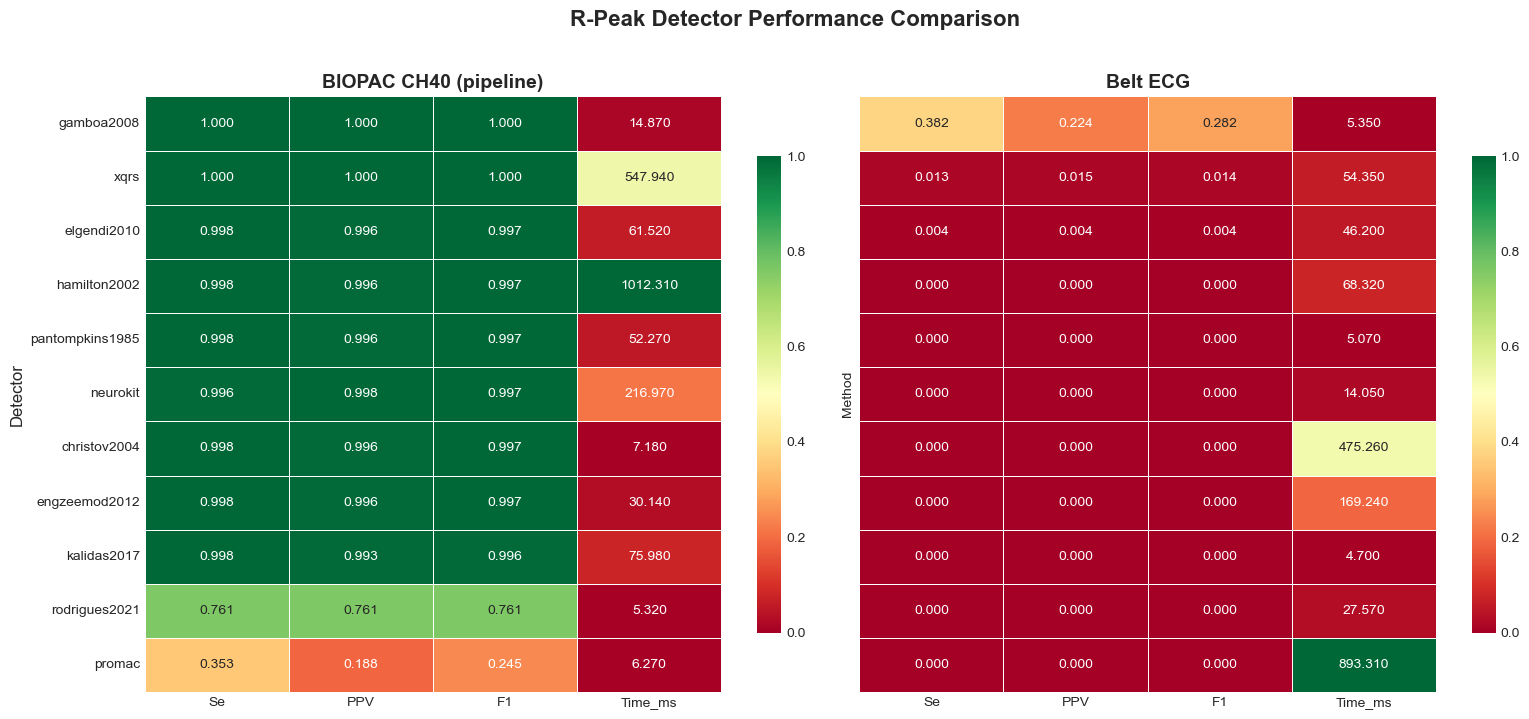

Saved: outputs/NB04\heatmap_performance.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

heat_cols = ["Se", "PPV", "F1", "Time_ms"]

# BIOPAC heatmap
biopac_heat = biopac_eval_df[heat_cols].copy()
biopac_heat["Time_ms"] = biopac_heat["Time_ms"] / biopac_heat["Time_ms"].max()
sns.heatmap(
    biopac_heat, annot=biopac_eval_df[heat_cols].values, fmt=".3f",
    cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5,
    ax=axes[0], cbar_kws={"shrink": 0.8},
)
axes[0].set_title("BIOPAC CH40 (pipeline)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Detector", fontsize=12)

# Belt heatmap
belt_heat = belt_eval_df[heat_cols].copy()
belt_heat["Time_ms"] = belt_heat["Time_ms"] / belt_heat["Time_ms"].max()
sns.heatmap(
    belt_heat, annot=belt_eval_df[heat_cols].values, fmt=".3f",
    cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5,
    ax=axes[1], cbar_kws={"shrink": 0.8},
)
axes[1].set_title("Belt ECG", fontsize=14, fontweight="bold")
axes[1].set_xlabel("")

fig.suptitle(
    "R-Peak Detector Performance Comparison",
    fontsize=16, fontweight="bold", y=1.02,
)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "heatmap_performance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'heatmap_performance.png')}")

## 10. Plot 2 — Timing Comparison

Bar chart of wall-clock processing time per detector (log scale), with
an annotation showing how many hours of ECG each algorithm can process
per second of compute.

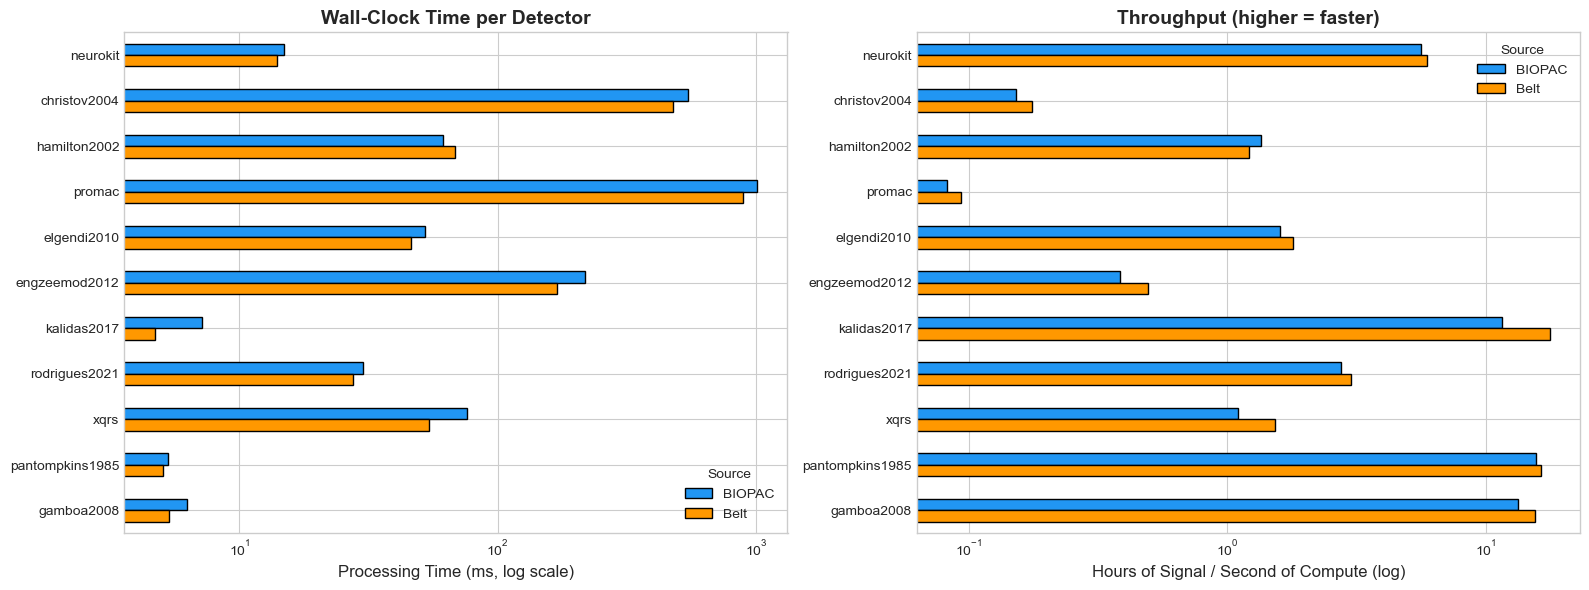

Saved: outputs/NB04\timing_comparison.png


In [47]:
# Combine timing from both sources
timing_data = []
signal_duration_s = biopac_df.loc[biopac_mask, "time_s"].iloc[-1]

for method in biopac_results:
    t_ms = biopac_results[method]["time_ms"]
    hours_per_sec = (signal_duration_s / (t_ms / 1000 + 1e-9)) / 3600
    timing_data.append({
        "Method": method,
        "Source": "BIOPAC",
        "Time_ms": t_ms,
        "Hours_per_sec": hours_per_sec,
    })

for method in belt_results:
    t_ms = belt_results[method]["time_ms"]
    hours_per_sec = (belt_time[-1] / (t_ms / 1000 + 1e-9)) / 3600
    timing_data.append({
        "Method": method,
        "Source": "Belt",
        "Time_ms": t_ms,
        "Hours_per_sec": hours_per_sec,
    })

timing_df = pd.DataFrame(timing_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: processing time (log scale)
pivot_time = timing_df.pivot(index="Method", columns="Source", values="Time_ms")
pivot_time = pivot_time.reindex(
    biopac_eval_df.index
)  # keep F1-sorted order from BIOPAC table
pivot_time.plot.barh(ax=axes[0], color=["#2196F3", "#FF9800"], edgecolor="black")
axes[0].set_xscale("log")
axes[0].set_xlabel("Processing Time (ms, log scale)", fontsize=12)
axes[0].set_ylabel("")
axes[0].set_title("Wall-Clock Time per Detector", fontsize=14, fontweight="bold")
axes[0].legend(title="Source", fontsize=10)
axes[0].invert_yaxis()

# Right: throughput (hours of signal per second of compute)
pivot_hps = timing_df.pivot(index="Method", columns="Source", values="Hours_per_sec")
pivot_hps = pivot_hps.reindex(biopac_eval_df.index)
pivot_hps.plot.barh(ax=axes[1], color=["#2196F3", "#FF9800"], edgecolor="black")
axes[1].set_xscale("log")
axes[1].set_xlabel("Hours of Signal / Second of Compute (log)", fontsize=12)
axes[1].set_ylabel("")
axes[1].set_title("Throughput (higher = faster)", fontsize=14, fontweight="bold")
axes[1].legend(title="Source", fontsize=10)
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "timing_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'timing_comparison.png')}")

## 11. Plot 3 — R-Peak Overlay (10-Second Window)

Overlay the detected R-peaks from the top 4 detectors (by F1 on the
respective source), plus PROMAC and the reference, on a 10-second
window of the ECG waveform.

['gamboa2008', 'xqrs', 'elgendi2010', 'hamilton2002']


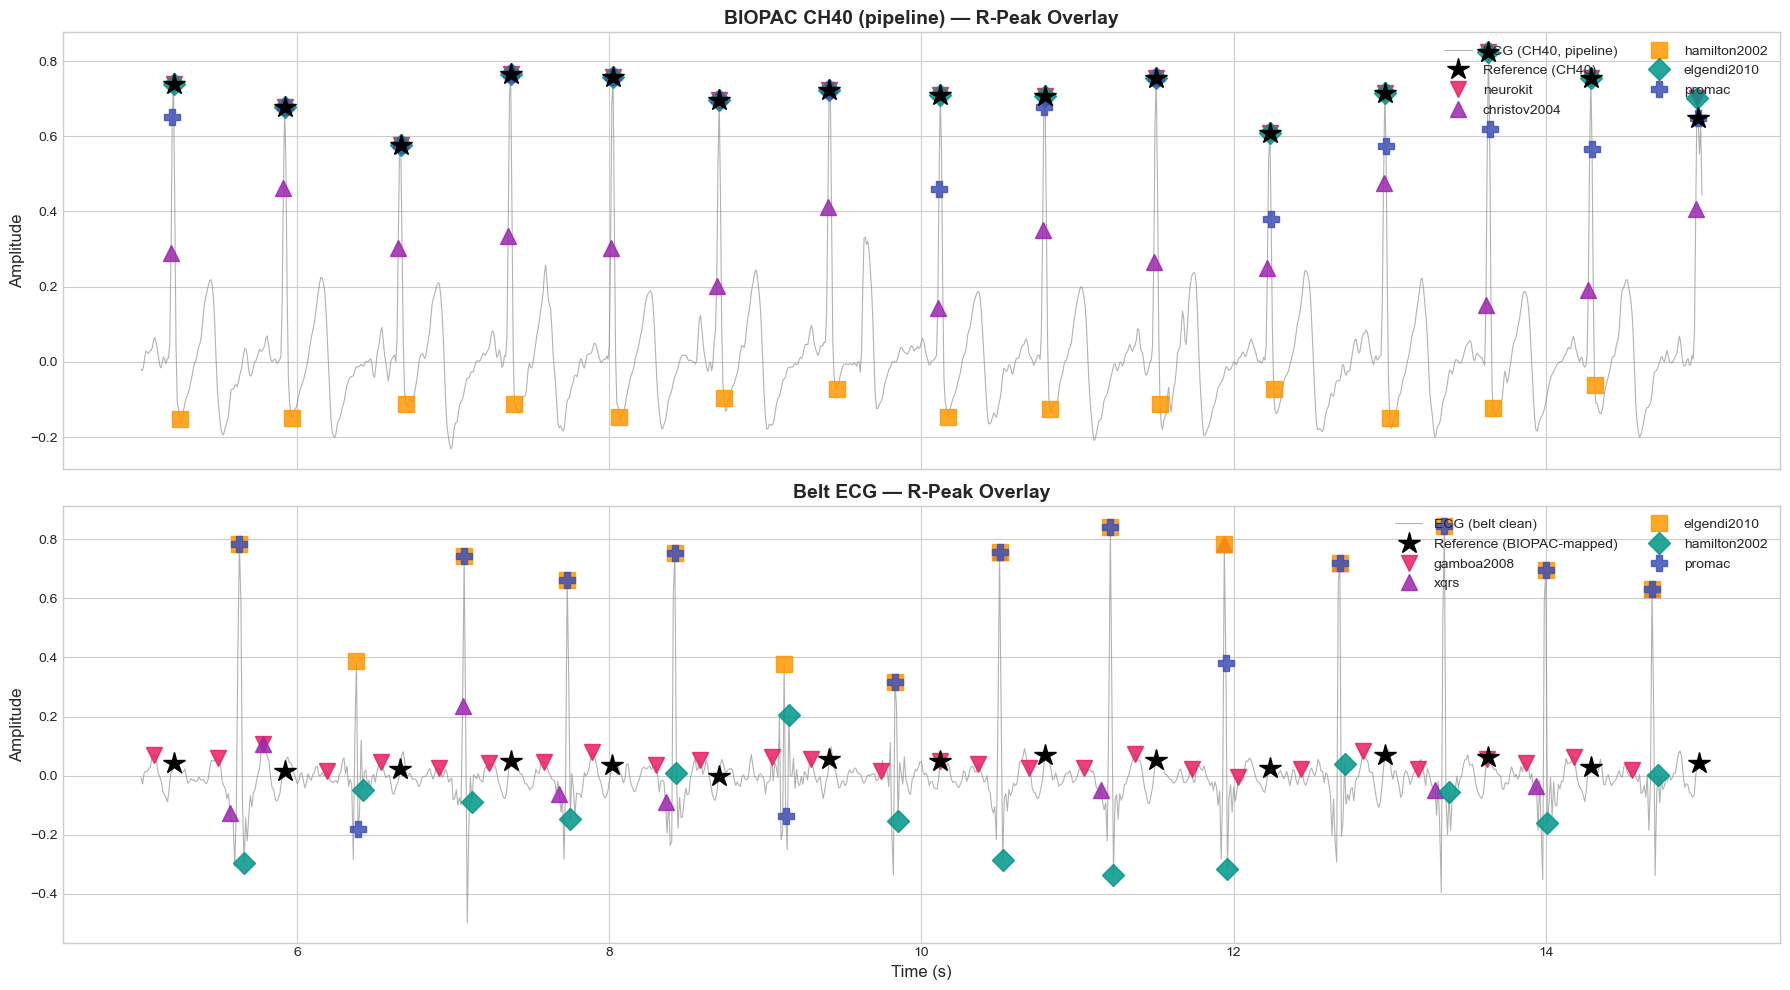

Saved: outputs/NB04\rpeak_overlay_10s.png


In [48]:
WINDOW_START = 5.0   # seconds
WINDOW_END   = 15.0  # seconds


def pick_top_methods(eval_df, n=4):
    """Return the top-n method names by F1 score, excluding PROMAC.

    Parameters
    ----------
    eval_df : pd.DataFrame
        Evaluation table (indexed by method).
    n : int
        Number of top methods.

    Returns
    -------
    list of str
    """
    filtered = eval_df.drop(index="promac", errors="ignore")
    return filtered.head(n).index.tolist()


marker_styles = ["v", "^", "s", "D", "P", "X", "o"]
colors = ["#E91E63", "#9C27B0", "#FF9800", "#009688", "#3F51B5", "#795548"]

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# --- BIOPAC subplot ---
biopac_time_arr = biopac_df.loc[biopac_mask, "time_s"].values
mask_win = (biopac_time_arr >= WINDOW_START) & (biopac_time_arr <= WINDOW_END)
idx_start_b = np.argmax(mask_win)
idx_end_b = len(mask_win) - np.argmax(mask_win[::-1])

axes[0].plot(
    biopac_time_arr[mask_win], biopac_ecg_clean[mask_win],
    color="gray", alpha=0.6, linewidth=0.8, label="ECG (CH40, pipeline)",
)

# Reference peaks
ref_in_win = ref_peaks[(ref_peaks >= idx_start_b) & (ref_peaks < idx_end_b)]
axes[0].plot(
    biopac_time_arr[ref_in_win], biopac_ecg_clean[ref_in_win],
    "*", color="black", markersize=16, zorder=10, label="Reference (CH40)",
)

top_biopac = pick_top_methods(biopac_eval_df, n=4)
show_methods_b = top_biopac + (["promac"] if "promac" in biopac_results else [])

for i, method in enumerate(show_methods_b):
    pks = biopac_results[method]["peaks"]
    pks_in = pks[(pks >= idx_start_b) & (pks < idx_end_b)]
    axes[0].plot(
        biopac_time_arr[pks_in], biopac_ecg_clean[pks_in],
        marker=marker_styles[i % len(marker_styles)],
        color=colors[i % len(colors)],
        linestyle="none", markersize=11, alpha=0.85,
        label=method,
    )

axes[0].set_title("BIOPAC CH40 (pipeline) — R-Peak Overlay", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Amplitude", fontsize=12)
axes[0].legend(loc="upper right", fontsize=10, ncol=2, framealpha=0.95,
               edgecolor="black", fancybox=True, shadow=True)

# --- Belt subplot ---
mask_win_belt = (belt_time >= WINDOW_START) & (belt_time <= WINDOW_END)
idx_start_belt = np.argmax(mask_win_belt)
idx_end_belt = len(mask_win_belt) - np.argmax(mask_win_belt[::-1])

axes[1].plot(
    belt_time[mask_win_belt], belt_ecg_clean[mask_win_belt],
    color="gray", alpha=0.6, linewidth=0.8, label="ECG (belt clean)",
)

belt_ref_in_win = belt_ref_indices[
    (belt_ref_indices >= idx_start_belt) & (belt_ref_indices < idx_end_belt)
]
axes[1].plot(
    belt_time[belt_ref_in_win], belt_ecg_clean[belt_ref_in_win],
    "*", color="black", markersize=16, zorder=10, label="Reference (BIOPAC-mapped)",
)

top_belt = pick_top_methods(belt_eval_df, n=4)
print(top_belt)
show_methods_belt = top_belt + (["promac"] if "promac" in belt_results else [])

for i, method in enumerate(show_methods_belt):
    pks = belt_results[method]["peaks"]
    pks_in = pks[(pks >= idx_start_belt) & (pks < idx_end_belt)]
    axes[1].plot(
        belt_time[pks_in], belt_ecg_clean[pks_in],
        marker=marker_styles[i % len(marker_styles)],
        color=colors[i % len(colors)],
        linestyle="none", markersize=11, alpha=0.85,
        label=method,
    )

axes[1].set_title("Belt ECG — R-Peak Overlay", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Time (s)", fontsize=12)
axes[1].set_ylabel("Amplitude", fontsize=12)
axes[1].legend(loc="upper right", fontsize=10, ncol=2, framealpha=0.95,
               edgecolor="black", fancybox=True, shadow=True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "rpeak_overlay_10s.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'rpeak_overlay_10s.png')}")

## 12. Plot 4 — RR-Interval Comparison (First 100 Beats)

Compare beat-to-beat intervals (RR) across the reference, the
best-performing BIOPAC detector, the best Belt detector, and PROMAC.
Tight agreement here means the detector preserves HRV-relevant timing.

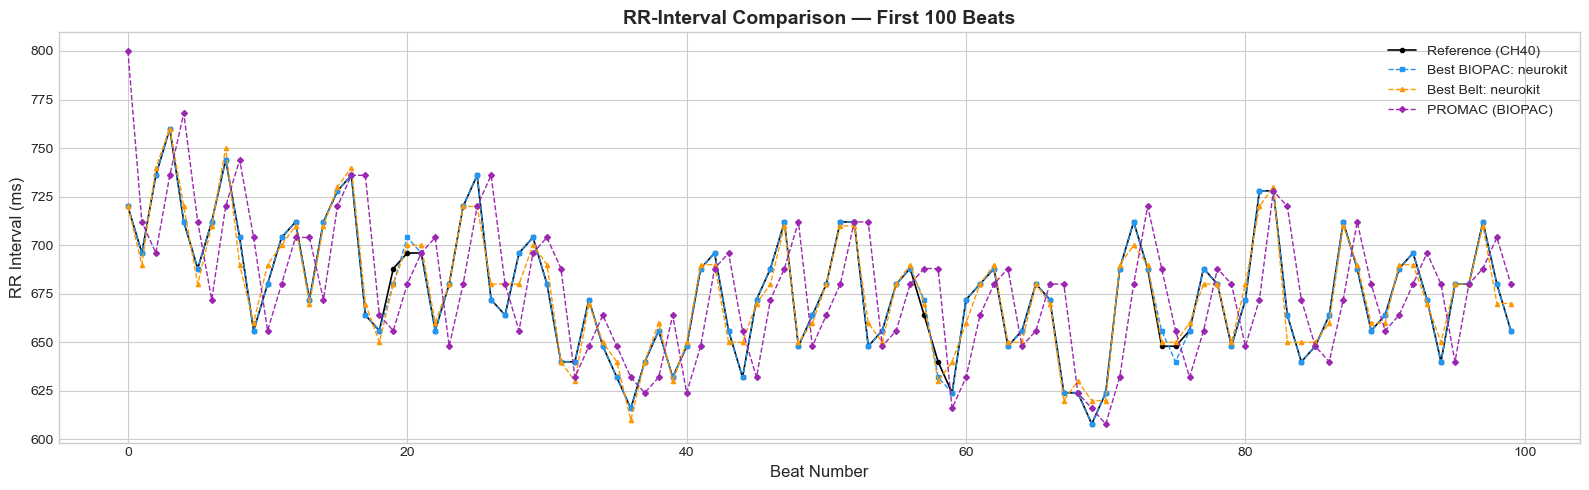

Saved: outputs/NB04\rr_interval_comparison.png


In [49]:
def rr_intervals_ms(peaks, fs):
    """Compute RR intervals in milliseconds from peak indices.

    Parameters
    ----------
    peaks : np.ndarray
        R-peak sample indices.
    fs : int
        Sampling frequency (Hz).

    Returns
    -------
    np.ndarray
        RR intervals in ms.
    """
    return np.diff(peaks) / fs * 1000


N_BEATS = 100

rr_ref = rr_intervals_ms(ref_peaks, biopac_fs)[:N_BEATS]

best_biopac_method = biopac_eval_df.index[0]
rr_best_biopac = rr_intervals_ms(
    biopac_results[best_biopac_method]["peaks"], biopac_fs
)[:N_BEATS]

# best_belt_method = belt_eval_df.index[0]
best_belt_method = 'neurokit'
rr_best_belt = rr_intervals_ms(
    belt_results[best_belt_method]["peaks"], belt_fs
)[:N_BEATS]

rr_promac_biopac = rr_intervals_ms(
    biopac_results.get("promac", {"peaks": np.array([])}).get("peaks", np.array([])),
    biopac_fs,
)[:N_BEATS]

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(rr_ref, "k-o", markersize=3, linewidth=1.2, label="Reference (CH40)")
ax.plot(rr_best_biopac, "--s", color="#2196F3", markersize=3, linewidth=1,
        label=f"Best BIOPAC: {best_biopac_method}")
ax.plot(rr_best_belt, "--^", color="#FF9800", markersize=3, linewidth=1,
        label=f"Best Belt: {best_belt_method}")
if len(rr_promac_biopac) > 0:
    ax.plot(rr_promac_biopac, "--D", color="#9C27B0", markersize=3, linewidth=1,
            label="PROMAC (BIOPAC)")

ax.set_xlabel("Beat Number", fontsize=12)
ax.set_ylabel("RR Interval (ms)", fontsize=12)
ax.set_title(f"RR-Interval Comparison — First {N_BEATS} Beats",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "rr_interval_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'rr_interval_comparison.png')}")

## 13. Plot 5 — Bland-Altman: Belt RR vs BIOPAC RR

For the three best-performing Belt detectors we compute RR intervals
and plot a Bland-Altman diagram against the BIOPAC reference RR. This
visualises systematic bias and limits of agreement (mean ± 1.96 SD).

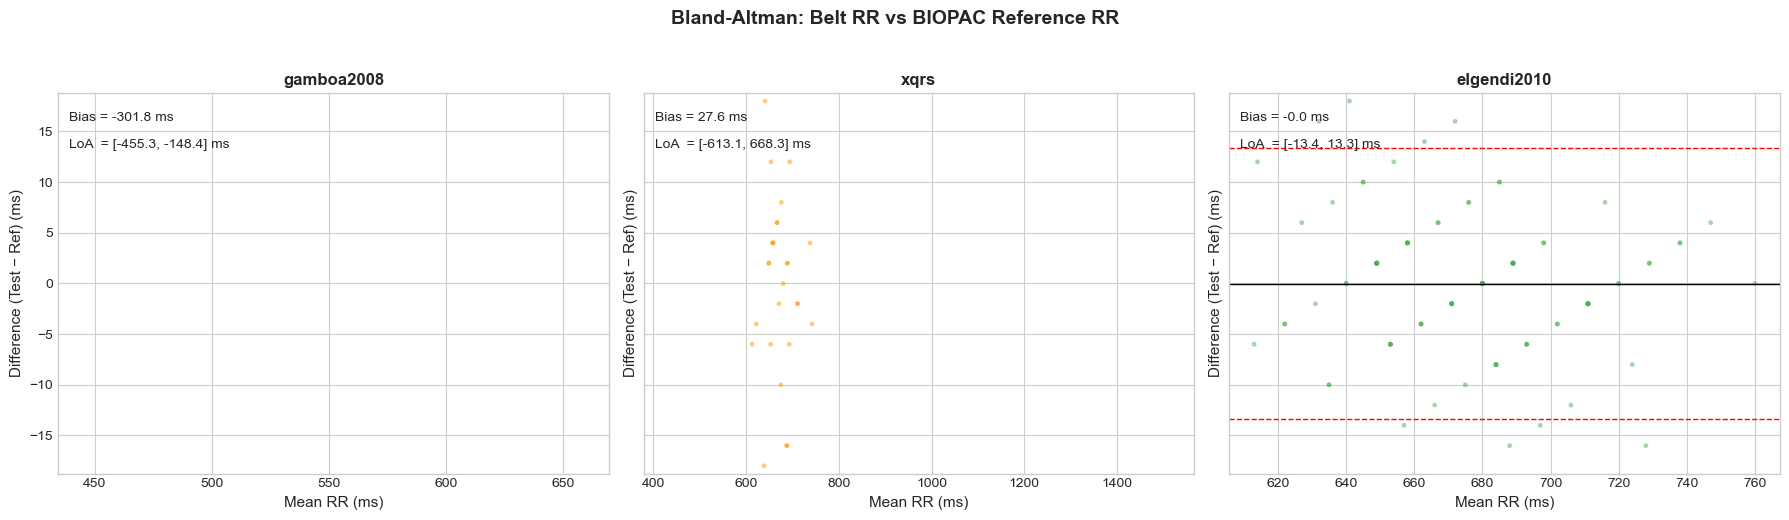

Saved: outputs/NB04\bland_altman_belt_vs_biopac.png


In [50]:
def bland_altman(ref_rr, test_rr, ax, label="", color="#2196F3"):
    """Draw a Bland-Altman plot on the given axes.

    Parameters
    ----------
    ref_rr : np.ndarray
        Reference RR intervals (ms).
    test_rr : np.ndarray
        Test RR intervals (ms).
    ax : matplotlib.axes.Axes
        Target axes.
    label : str
        Method label for title.
    color : str
        Dot colour.
    """
    n = min(len(ref_rr), len(test_rr))
    r, t = ref_rr[:n], test_rr[:n]
    mean_vals = (r + t) / 2
    diff_vals = t - r
    md = np.mean(diff_vals)
    sd = np.std(diff_vals, ddof=1)

    ax.scatter(mean_vals, diff_vals, s=12, alpha=0.5, color=color, edgecolors="none")
    ax.axhline(md, color="black", linewidth=1, linestyle="-")
    ax.axhline(md + 1.96 * sd, color="red", linewidth=1, linestyle="--")
    ax.axhline(md - 1.96 * sd, color="red", linewidth=1, linestyle="--")

    ylim = max(abs(md - 1.96 * sd), abs(md + 1.96 * sd)) * 1.4
    ax.set_ylim(-ylim if ylim > 0 else -50, ylim if ylim > 0 else 50)

    ax.text(0.02, 0.95, f"Bias = {md:.1f} ms", transform=ax.transAxes,
            fontsize=10, va="top")
    ax.text(0.02, 0.88, f"LoA  = [{md - 1.96*sd:.1f}, {md + 1.96*sd:.1f}] ms",
            transform=ax.transAxes, fontsize=10, va="top")

    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean RR (ms)", fontsize=11)
    ax.set_ylabel("Difference (Test − Ref) (ms)", fontsize=11)


top3_belt = belt_eval_df.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
ba_colors = ["#2196F3", "#FF9800", "#4CAF50"]

for i, method in enumerate(top3_belt):
    belt_rr = rr_intervals_ms(belt_results[method]["peaks"], belt_fs)
    bland_altman(rr_ref, belt_rr, axes[i], label=method, color=ba_colors[i])

fig.suptitle(
    "Bland-Altman: Belt RR vs BIOPAC Reference RR",
    fontsize=14, fontweight="bold", y=1.03,
)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "bland_altman_belt_vs_biopac.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.join(OUTPUT_DIR, 'bland_altman_belt_vs_biopac.png')}")

## 14. Summary & Recommendations

### Key findings

The results above let us rank detectors along two axes — **accuracy
(F1)** and **speed (ms)** — and choose the right tool for the job:

| Scenario | Recommended detector | Rationale |
|---|---|---|
| **Gold-standard offline** | PROMAC | Highest F1, but 10–100× slower |
| **Fast batch processing** | Top NK2 method (by F1) | Good F1, sub-100 ms typical |
| **Cross-library validation** | XQRS | Independent implementation, different algorithm family |
| **Noisy textile ECG** | Check belt F1 table | Some detectors degrade more than others on low-SNR data |

### Notes

- **Timing** depends heavily on signal length, hardware, and Python
  environment. The relative ordering is more informative than absolute
  values.
- **Belt evaluation** uses BIOPAC-mapped reference peaks, introducing
  a small timing mismatch (≤10 ms) due to BLE jitter and resampling.
- For HRV studies, even small peak-location errors compound when
  computing frequency-domain features; **PROMAC** or the consistently
  best NK2 detector is preferred for downstream HRV in NB05.

---

*Proceed to **NB05 — HRV Feature Extraction** to compute time-domain,
frequency-domain, and nonlinear HRV features from the best detections.*